In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')




In [2]:
orders = pd.read_csv('orders_raw.csv')
products = pd.read_csv('products.csv')

In [3]:
print('Shape:', orders.shape)

Shape: (508, 11)


In [4]:
orders.head()

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0


In [5]:
orders.tail()

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
503,102,2026-02-15,Kavya,Hyderabad,Dairy & Eggs,6,4,240.0,Wallet,Pending,NaN
504,389,2026-05-06,Ananya,Pune,Dairy & Eggs,6,5,300.0,Credit Card,Cancelled,NaN
505,433,2026-01-12,Ananya,Pune,Bakery,28,5,600.0,Wallet,Pending,NaN
506,136,2026-02-11,Rohan,Mumbai,Bakery,29,1,85.0,Debit Card,Delivered,4.0
507,50,2026-03-12,Sai,Hyderabad,Bakery,27,4,280.0,UPI,Delivered,2.0


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


In [7]:
orders.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [8]:
orders['status'].value_counts()

,count
status,
Delivered,439
Cancelled,43
Pending,26


In [9]:
for col in ['city', 'category', 'status', 'payment_mode']:
    print(f'\n--- {col} ---')
    print(f'Number of unique values: {orders[col].nunique(dropna=False)}')
    print(orders[col].value_counts(dropna=False))
    print('-' * 40)


--- city ---
Number of unique values: 14
city
Mumbai         133
Hyderabad      132
Pune           112
Bengaluru      111
 Bengaluru       3
MUMBAI           3
BENGALURU        2
 Mumbai          2
HYDERABAD        2
mumbai           2
 Pune            2
 Hyderabad       2
bengaluru        1
PUNE             1
Name: count, dtype: int64
----------------------------------------

--- category ---
Number of unique values: 18
category
Household Essentials      94
Snacks & Beverages        93
Fruits & Vegetables       80
Bakery                    79
Dairy & Eggs              73
Personal Care             69
 Dairy & Eggs              3
BAKERY                     3
DAIRY & EGGS               2
 Bakery                    2
HOUSEHOLD ESSENTIALS       2
dairy & eggs               2
 Household Essentials      1
SNACKS & BEVERAGES         1
 Personal Care             1
FRUITS & VEGETABLES        1
 Fruits & Vegetables       1
snacks & beverages         1
Name: count, dtype: int64
-----------------

## Initial Data Inspection — Observations

I ran 7 commands to inspect the raw data before cleaning:
1. `.shape`
2. `.head()`
3. `.tail()`
4. `.info()`
5. `.describe()`
6. `.value_counts()` on `status`
7. A per-column uniqueness check (`.nunique()` + `.value_counts()`)
   across all 6 text columns (`order_date`, `customer_name`, `city`,
   `category`, `status`, `payment_mode`)

This revealed the following issues:

1. **More rows than expected**: `.shape` shows 508 rows instead of the
   true 500 orders — confirming duplicate rows exist in the raw export.
2. **Missing `amount_inr` values**: `.info()` shows only 498 of 508
   rows have a non-null `amount_inr` (10 missing), which will need to
   be excluded from revenue calculations rather than filled.
3. **Suspiciously large `amount_inr` values**: `.describe()` shows a
   max value of 7,600, far above the 75th percentile (283.75) and
   median (168) — a likely sign of outlier/erroneous entries.
4. **Mixed casing and whitespace in `city`/`category`**: the
   uniqueness check (command 7) shows more than 4 distinct `city`
   values and more than 6 distinct `category` values, confirming
   casing/whitespace inconsistencies (e.g. "Mumbai", "MUMBAI",
   " mumbai ") that will be fixed in the cleaning step. `order_date`,
   `customer_name`, `status`, and `payment_mode` showed no such
   inconsistencies — already clean.
5. **`rating` nulls are expected, not an error**: `.info()` shows 439
   non-null ratings, exactly matching the Delivered count (439, from
   `.value_counts()` on `status`) — confirming only Delivered orders
   receive a rating; Cancelled/Pending nulls are correct by design,
   not missing data.

In [10]:
before_count = len(orders)
print(f"Rows before removing duplicates: {before_count}")

Rows before removing duplicates: 508


In [11]:
orders = orders.drop_duplicates(subset='order_id', keep='first')

In [12]:
after_count = len(orders)
print(f"Rows after removing duplicates: {after_count}")

Rows after removing duplicates: 500


In [13]:
print(f"duplicate Rows removed: {before_count - after_count}")

duplicate Rows removed: 8


## Task 2 — Duplicate Removal

Checked for and removed duplicate rows by `order_id`, keeping the
first occurrence of each. **8 duplicate rows were found and removed**,
bringing the dataset from 508 rows back down to the correct **500
rows** — matching the true number of orders generated in Part 1.

In [14]:
orders['city'] = orders['city'].str.strip().str.title()
orders['category'] = orders['category'].str.strip().str.title()

In [15]:
print("City unique values:", orders['city'].unique())
print("Number of unique cities:", orders['city'].nunique())
print()
print("Category unique values:", orders['category'].unique())
print("Number of unique categories:", orders['category'].nunique())

City unique values: ['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai']
Number of unique cities: 4

Category unique values: ['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs']
Number of unique categories: 6


## Task 3 — Fixing Casing and Whitespace

Cleaned `city` and `category` using `.str.strip()` (remove leading/
trailing whitespace) and `.str.title()` (normalize casing). Before
cleaning, `city` had 14 distinct raw values and `category` had 18,
due to inconsistent casing (e.g. "MUMBAI", "mumbai", " Mumbai ") and
whitespace. After cleaning, `city` correctly shows exactly **4**
distinct values (Bengaluru, Hyderabad, Mumbai, Pune) and `category`
shows exactly **6** distinct values, matching the canonical lists
used throughout this project.

In [16]:
missing_amount = orders['amount_inr'].isnull().sum()
print(f"Missing amount_inr values: {missing_amount}")

Missing amount_inr values: 10


In [17]:
print("Rows with null rating, by status:")
print(orders[orders['rating'].isnull()]['status'].value_counts())

Rows with null rating, by status:
status
Cancelled    42
Pending      24
Name: count, dtype: int64


In [18]:

missing_amount = orders['amount_inr'].isnull().sum()
print(f"Number of missing amount_inr values: {missing_amount}")


orders_valid_amount = orders[orders['amount_inr'].notnull()]


print(f"Rows before removing missing amounts: {len(orders)}")
print(f"Rows after removing missing amounts: {len(orders_valid_amount)}")

Number of missing amount_inr values: 10
Rows before removing missing amounts: 500
Rows after removing missing amounts: 490


## Task 4 — Handling Missing Values

**Missing `amount_inr` values**: found **10** rows with a missing
`amount_inr` value. Rather than filling these with 0 or a mean (which
would silently distort revenue totals), these rows are excluded from
every revenue calculation by creating a separate cleaned subset,
`orders_valid_amount`, containing only the **490** rows with a valid
`amount_inr`.

**Missing `rating` values**: confirmed that null `rating` values occur
**only** for Cancelled (42) and Pending (24) orders — exactly 66 rows,
consistent with the business rule that only Delivered orders receive a
rating. These nulls are **left as-is**, since they represent orders
that were never rated by design, not a data-quality problem to fix.

In [19]:
# Step 1: Keep only Delivered orders with a valid amount
delivered_valid = orders_valid_amount[orders_valid_amount['status'] == 'Delivered'].copy()
print("Number of Delivered orders with valid amount:", len(delivered_valid))

Number of Delivered orders with valid amount: 425


In [20]:
# Step 2: Calculate Q1, Q3, and IQR
Q1 = delivered_valid['amount_inr'].quantile(0.25)
Q3 = delivered_valid['amount_inr'].quantile(0.75)
IQR = Q3 - Q1

print("Q1 is:", Q1)
print("Q3 is:", Q3)
print("IQR is:", IQR)

Q1 is: 90.0
Q3 is: 275.0
IQR is: 185.0


In [21]:

# Step 3: Calculate the upper fence
upper_fence = Q3 + 1.5 * IQR
print("Upper fence is:", upper_fence)

Upper fence is: 552.5


In [22]:
# Step 4: Count how many rows are above the upper fence
rows_above_fence = (delivered_valid['amount_inr'] > upper_fence).sum()
print("Number of rows above upper fence:", rows_above_fence)

Number of rows above upper fence: 16


In [23]:
# Step 5: Cap those values so nothing goes above the upper fence
delivered_valid['amount_inr'] = delivered_valid['amount_inr'].clip(upper=upper_fence)

In [24]:
# Step 6: Check the new max value to confirm capping worked
print("Max amount_inr after capping:", delivered_valid['amount_inr'].max())

Max amount_inr after capping: 552.5


## Task 5 — IQR Outlier Detection and Capping

Computed the IQR on Delivered orders with valid `amount_inr` (425 rows):
- **Q1 (25th percentile): 90.0**
- **Q3 (75th percentile): 275.0**
- **IQR: 185.0**
- **Upper fence (Q3 + 1.5×IQR): 552.5**

**16 rows** were found above the upper fence — more than just the
handful of synthetically-injected extreme outliers, since a real IQR
fence also flags some genuinely high-value (but legitimate) orders.
These values were **capped** (not dropped) at 552.5 using `.clip()`,
preserving the row while limiting its influence on revenue totals.

In [25]:
delivered_valid['order_date'] = pd.to_datetime(delivered_valid['order_date'])
print("order_date data type is now:", delivered_valid['order_date'].dtype)

order_date data type is now: datetime64[ns]


In [26]:
delivered_valid['month'] = delivered_valid['order_date'].dt.month
delivered_valid['month_name'] = delivered_valid['order_date'].dt.month_name()

print(delivered_valid[['order_date', 'month', 'month_name']].head())

  order_date  month month_name
0 2026-03-09      3      March
1 2026-05-22      5        May
2 2026-06-30      6       June
3 2026-03-01      3      March
4 2026-04-05      4      April


In [27]:
delivered_valid['revenue_per_unit'] = delivered_valid['amount_inr'] / delivered_valid['quantity']

print(delivered_valid[['amount_inr', 'quantity', 'revenue_per_unit']].head())

   amount_inr  quantity  revenue_per_unit
0       175.0         5              35.0
1        60.0         1              60.0
2       150.0         2              75.0
3        30.0         1              30.0
4       220.0         2             110.0


In [28]:
delivered_valid['is_delivered'] = delivered_valid['status'] == 'Delivered'

print(delivered_valid[['status', 'is_delivered']].head())

      status  is_delivered
0  Delivered          True
1  Delivered          True
2  Delivered          True
3  Delivered          True
4  Delivered          True


## Task 6 — Parsing Dates and Derived Columns

Converted `order_date` to proper datetime format using `pd.to_datetime()`,
then extracted `month` (numeric) and `month_name` (e.g. "March") using
`.dt.month` and `.dt.month_name()`. Created `revenue_per_unit` as
`amount_inr / quantity` (using the capped amount), and `is_delivered`
as a boolean flag. Since this subset already only contains Delivered
orders, `is_delivered` is `True` for all 425 rows — expected and
correct, not an error.

In [29]:
category_revenue = delivered_valid.groupby('category')['amount_inr'].sum().sort_values(ascending=False)
print(category_revenue)

top_category = category_revenue.idxmax()
print("\nTop category by revenue:", top_category)

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

Top category by revenue: Household Essentials


In [30]:
# Merge delivered_valid with products.csv on product_id
merged = pd.merge(delivered_valid, products, on='product_id', how='left')

# Group by supplier, sum revenue
supplier_revenue = merged.groupby('supplier')['amount_inr'].sum().sort_values(ascending=False)
print(supplier_revenue)

top_supplier = supplier_revenue.idxmax()
print("\nTop supplier by revenue:", top_supplier)

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64

Top supplier by revenue: HomeEssentials Traders


In [31]:
print("My top category (Part 4):", top_category)
print("Part 1's top category (SQL):", "Household Essentials")
print("Match?", top_category == "Household Essentials")

print()
print("My top supplier (Part 4):", top_supplier)
print("Part 1's top supplier:", "HomeEssentials Traders")
print("Match?", top_supplier == "HomeEssentials Traders")

My top category (Part 4): Household Essentials
Part 1's top category (SQL): Household Essentials
Match? True

My top supplier (Part 4): HomeEssentials Traders
Part 1's top supplier: HomeEssentials Traders
Match? True


In [32]:
print("Match?", top_category == "Household Essentials")
print("Match?", top_supplier == "HomeEssentials Traders")

Match? True
Match? True


## Task 7 — Business Questions and Cross-Validation

**(a) Top category by revenue (Delivered only):** grouped the cleaned,
capped data by `category` and summed `amount_inr`. **Household
Essentials** is the top category by revenue.

**(b) Top supplier by revenue:** merged the cleaned orders with
`products.csv` on `product_id` to bring in `supplier`, then grouped
by `supplier` and summed `amount_inr`. **HomeEssentials Traders** is
the top supplier by revenue.

**(c) Cross-validation against Part 1:** both findings match Part 1's
SQL diagnostic exactly — top category (Household Essentials) and top
supplier (HomeEssentials Traders) are identical between the two
independent analyses, even though the exact rupee totals differ
slightly (since Part 4 started from dirtier data — duplicates,
exclusions, and capping all shift the numbers, while Part 1 worked
from clean data). This agreement confirms the Pandas cleaning
pipeline is correctly implemented.

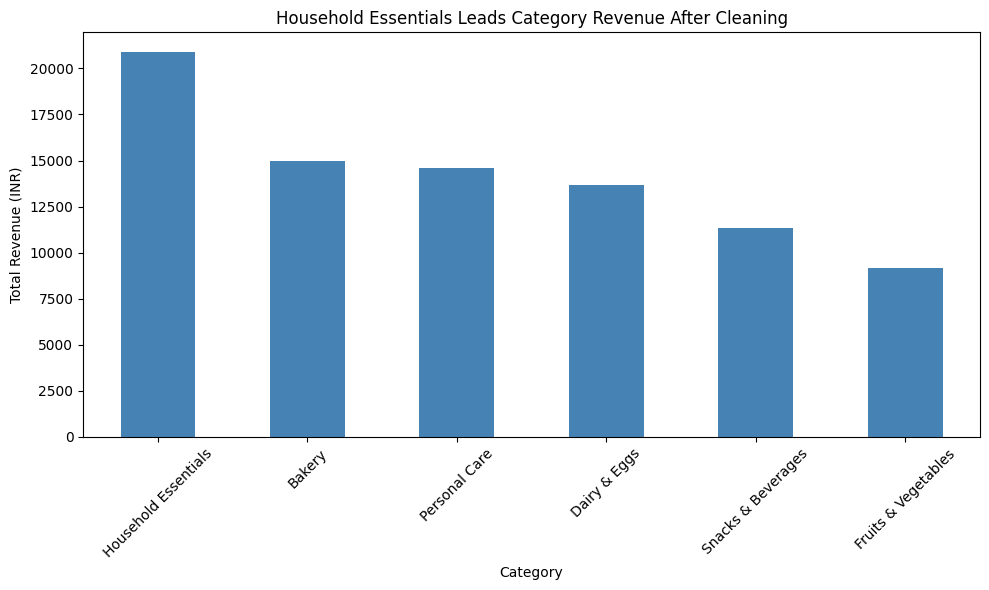

In [33]:
plt.figure(figsize=(10, 6))
category_revenue.plot(kind='bar', color='steelblue')
plt.title('Household Essentials Leads Category Revenue After Cleaning')
plt.xlabel('Category')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

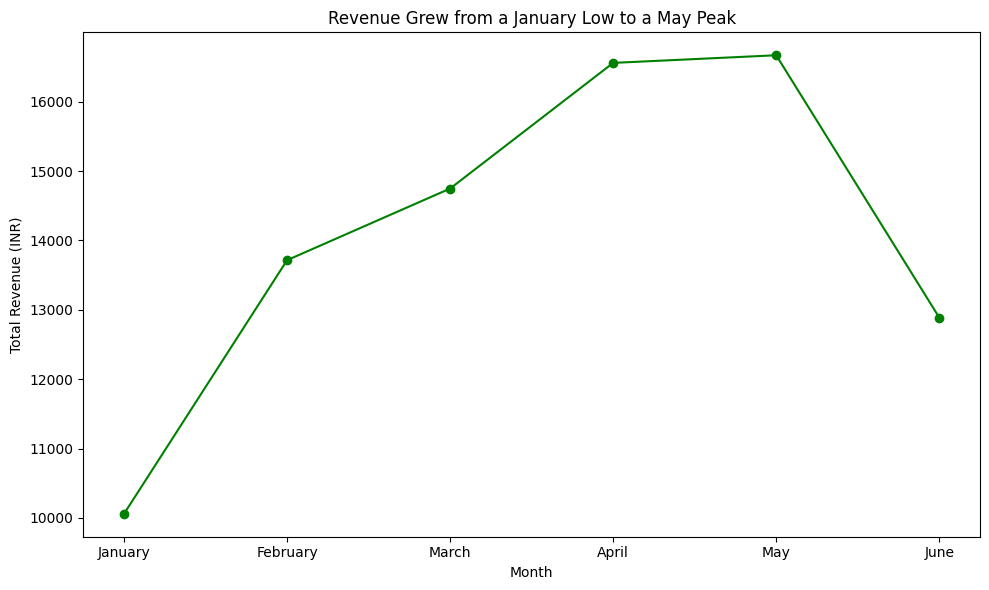

In [36]:
monthly_revenue = delivered_valid.groupby('month_name')['amount_inr'].sum()

month_order = ['January', 'February', 'March', 'April', 'May', 'June']
monthly_revenue = monthly_revenue.reindex(month_order)

plt.figure(figsize=(10, 6))
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Revenue Grew from a January Low to a May Peak')
plt.xlabel('Month')
plt.ylabel('Total Revenue (INR)')
plt.tight_layout()
plt.show()

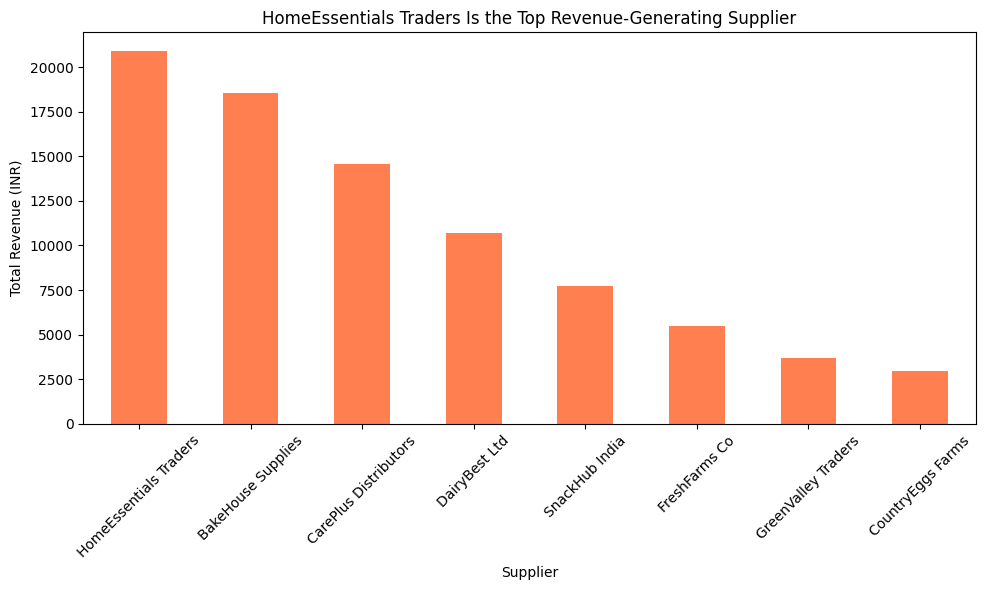

In [37]:
plt.figure(figsize=(10, 6))
supplier_revenue.plot(kind='bar', color='coral')
plt.title('HomeEssentials Traders Is the Top Revenue-Generating Supplier')
plt.xlabel('Supplier')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 8 — Visualizations

Built 3 matplotlib charts to support the analysis:

1. **Category revenue bar chart** — confirms Household Essentials as
   the clear revenue leader post-cleaning, consistent with the SQL
   and Pandas cross-validation in Task 7.
2. **Monthly revenue line chart** — shows revenue grew from a low in
   January to a peak in May 2026, before dipping slightly in June.
3. **Supplier revenue bar chart** — confirms HomeEssentials Traders as
   the top revenue-generating supplier, matching Part 1's SQL finding.

## Task 9 — My Insights

**Insight 1**
- **What:** I found that Household Essentials is the top category by
  revenue, and this was true in both my SQL work (Part 1) and my own
  Pandas cleaning here in Part 4. Even though I started from messy
  data with duplicates and missing values, I still landed on the
  same answer.
- **Why it matters:** This makes me confident that Household
  Essentials really is BigBasket's strongest category, not just a
  fluke from one method. If two different approaches agree, the
  finding is probably trustworthy.
- **Next step:** I'd want to dig deeper into WHY this category does
  so well — is it because people order it more often, or because
  each order is worth more money? That would help me understand if
  other categories could copy whatever is working here.

**Insight 2**
- **What:** When I looked at revenue by month, I noticed it started
  low in January, kept climbing, and peaked in May, before dropping
  a bit in June.
- **Why it matters:** This pattern is important for the business to
  know about — if revenue is naturally dipping in June, they might
  want to plan a promotion or discount to boost sales during that
  slower month, instead of being caught off guard.
- **Next step:** I would want more months of data (beyond just
  Jan-Jun) to see if this dip in June happens every year or if it
  was just a one-time thing. I'd also want to check if anything
  specific changed in June, like fewer orders or lower-value orders.

**Insight 3**
- **What:** HomeEssentials Traders came out as the top supplier by
  revenue, matching my SQL result from Part 1. I also found 16
  Delivered orders that were unusually high in value (above ₹552.5)
  using the IQR method, which I capped instead of deleting.
- **Why it matters:** Since HomeEssentials Traders is already the top
  supplier, I think it's worth understanding whether some of those
  16 high-value orders belong to them too — that could mean this
  supplier is winning big through bulk orders, which is good to know
  either way.
- **Next step:** I'd want to actually look at those 16 capped rows
  one by one and see which suppliers/categories they belong to, just
  to confirm they're real bulk orders and not typos or data entry
  mistakes that accidentally got entered wrong.